In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv(r"C:\Users\Lenovo\Documents\learnData.csv", encoding='latin1')

In [5]:
print(df.head())
print(df.info())
print(df.describe(include='all'))

                                        name  \
0                          Manhattan Dentist   
1                           David A Nusblatt   
2           Preferred Dental Care of Chelsea   
3                     Joanna Tricorache, DDS   
4  Herald Square Dental & The Denture Center   

                                   address           phone  \
0  551 5th Ave Rm 1114, New York, NY 10176  (917) 503-9164   
1         10 E 40th St, New York, NY 10016  (212) 473-2164   
2        135 W 27th St, New York, NY 10001  (646) 759-4489   
3   31 Washington Sq W, New York, NY 10011  (646) 835-0172   
4  224 W 35th St Fl 16, New York, NY 10001  (212) 689-0024   

                              website  rating  \
0  https://www.manhattannydentist.com     NaN   
1       http://www.nusblattdental.com     5.0   
2    http://www.chelseadentalcare.com     4.0   
3     http://www.teeththatsparkle.com     5.0   
4   http://www.heraldsquaredental.com     5.0   

                                       revi

In [6]:
print(df.isnull().sum())

name               0
address            0
phone              0
website          320
rating           777
reviewSnippet    777
dtype: int64


In [7]:
#data cleaning
print(df['reviewSnippet'].sample(5))

802    NaN
929    NaN
518    NaN
236    NaN
360    NaN
Name: reviewSnippet, dtype: object


In [11]:
# Drop rows missing reviewSnippet
print("Before cleaning shape:", df.shape)
df = df.dropna(subset=['reviewSnippet'])
print("After cleaning shape:", df.shape)

Before cleaning shape: (223, 7)
After cleaning shape: (223, 7)


In [12]:
median_rating = df['rating'].median()
df['rating'] = df['rating'].fillna(median_rating)

In [13]:
print(df.head())

                                        name  \
1                           David A Nusblatt   
2           Preferred Dental Care of Chelsea   
3                     Joanna Tricorache, DDS   
4  Herald Square Dental & The Denture Center   
5                Dr. Simon W. Rosenberg, DMD   

                                    address           phone  \
1          10 E 40th St, New York, NY 10016  (212) 473-2164   
2         135 W 27th St, New York, NY 10001  (646) 759-4489   
3    31 Washington Sq W, New York, NY 10011  (646) 835-0172   
4   224 W 35th St Fl 16, New York, NY 10001  (212) 689-0024   
5  399 E 72nd St Apt 1a, New York, NY 10021  (212) 988-8822   

                             website  rating  \
1      http://www.nusblattdental.com     5.0   
2   http://www.chelseadentalcare.com     4.0   
3    http://www.teeththatsparkle.com     5.0   
4  http://www.heraldsquaredental.com     5.0   
5    http://www.drsimonrosenberg.com     5.0   

                                       revi

In [14]:
#normalization
import string

# Convert to lowercase
df['clean_text'] = df['reviewSnippet'].str.lower()

# Remove punctuation
df['clean_text'] = df['clean_text'].str.replace(f"[{string.punctuation}]", "", regex=True)

# Remove special characters (keep only letters and spaces)
df['clean_text'] = df['clean_text'].str.replace(r'[^a-z\s]', '', regex=True)

# Remove extra spaces
df['clean_text'] = df['clean_text'].str.strip()
df['clean_text'] = df['clean_text'].str.replace(r'\s+', ' ', regex=True)

# Print first 5 rows to confirm
print(df[['reviewSnippet', 'clean_text']].head())

                                       reviewSnippet  \
1  Dr. David A. Nusblatt's involvement further en...   
2  I visited the dental clinic for a cleaning app...   
3  The use of modern dental technology at Dr. Tri...   
4  Dr. Pasch is wonderful!! Best fitting dentures...   
5  Had a minor dental emergency while on holiday ...   

                                          clean_text  
1  dr david a nusblatts involvement further enhan...  
2  i visited the dental clinic for a cleaning app...  
3  the use of modern dental technology at dr tric...  
4  dr pasch is wonderful best fitting dentures an...  
5  had a minor dental emergency while on holiday ...  


In [16]:
#tokenization
import nltk

# Download both punkt and punkt_tab
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [18]:
df['tokens'] = df['clean_text'].apply(nltk.word_tokenize)
print(df[['clean_text', 'tokens']].head())

                                          clean_text  \
1  dr david a nusblatts involvement further enhan...   
2  i visited the dental clinic for a cleaning app...   
3  the use of modern dental technology at dr tric...   
4  dr pasch is wonderful best fitting dentures an...   
5  had a minor dental emergency while on holiday ...   

                                              tokens  
1  [dr, david, a, nusblatts, involvement, further...  
2  [i, visited, the, dental, clinic, for, a, clea...  
3  [the, use, of, modern, dental, technology, at,...  
4  [dr, pasch, is, wonderful, best, fitting, dent...  
5  [had, a, minor, dental, emergency, while, on, ...  


In [19]:
#removal of stopwords
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already
nltk.download('stopwords')

# Define English stopwords
stop_words = set(stopwords.words('english'))

# Remove stopwords from tokens
df['tokens_no_stop'] = df['tokens'].apply(lambda x: [word for word in x if word not in stop_words])

# Print first 5 rows to confirm
print(df[['tokens', 'tokens_no_stop']].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


                                              tokens  \
1  [dr, david, a, nusblatts, involvement, further...   
2  [i, visited, the, dental, clinic, for, a, clea...   
3  [the, use, of, modern, dental, technology, at,...   
4  [dr, pasch, is, wonderful, best, fitting, dent...   
5  [had, a, minor, dental, emergency, while, on, ...   

                                      tokens_no_stop  
1  [dr, david, nusblatts, involvement, enhanced, ...  
2  [visited, dental, clinic, cleaning, appointmen...  
3  [use, modern, dental, technology, dr, tricorac...  
4  [dr, pasch, wonderful, best, fitting, dentures...  
5  [minor, dental, emergency, holiday, manhattan,...  


In [20]:
# lemmatization
import nltk
from nltk.stem import WordNetLemmatizer

# Download WordNet if not already
nltk.download('wordnet')
nltk.download('omw-1.4')  # optional, improves lemmatization

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization to tokens without stopwords
df['lemmatized_tokens'] = df['tokens_no_stop'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

# Print first 5 rows to confirm
print(df[['tokens_no_stop', 'lemmatized_tokens']].head())

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...


                                      tokens_no_stop  \
1  [dr, david, nusblatts, involvement, enhanced, ...   
2  [visited, dental, clinic, cleaning, appointmen...   
3  [use, modern, dental, technology, dr, tricorac...   
4  [dr, pasch, wonderful, best, fitting, dentures...   
5  [minor, dental, emergency, holiday, manhattan,...   

                                   lemmatized_tokens  
1  [dr, david, nusblatts, involvement, enhanced, ...  
2  [visited, dental, clinic, cleaning, appointmen...  
3  [use, modern, dental, technology, dr, tricorac...  
4  [dr, pasch, wonderful, best, fitting, denture,...  
5  [minor, dental, emergency, holiday, manhattan,...  


In [21]:
#sentimental loading
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download VADER lexicon if not already
nltk.download('vader_lexicon')

# Initialize analyzer
sia = SentimentIntensityAnalyzer()

# Apply sentiment scoring
df['sentiment_score'] = df['clean_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Convert score into sentiment label
df['sentiment_label'] = df['sentiment_score'].apply(
    lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral')
)

# Print first 10 rows to confirm
print(df[['clean_text', 'sentiment_score', 'sentiment_label']].head(10))

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...


                                           clean_text  sentiment_score  \
1   dr david a nusblatts involvement further enhan...           0.4939   
2   i visited the dental clinic for a cleaning app...           0.7096   
3   the use of modern dental technology at dr tric...           0.7351   
4   dr pasch is wonderful best fitting dentures an...           0.9136   
5   had a minor dental emergency while on holiday ...           0.4767   
8   dr amirian has been my dentist for few years a...           0.6908   
10  i like when doctor massiah plays music when do...           0.5423   
11  ive been a long time patient and have only ver...           0.5984   
12  extremely knowledgeable of craft with sincere ...           0.7096   
13  ive been a patient for many years now im alway...           0.8020   

   sentiment_label  
1         positive  
2         positive  
3         positive  
4         positive  
5         positive  
8         positive  
10        positive  
11        positiv

In [22]:
#TF-IDF vectorization 
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=5000)  # limit to top 5000 words

# Fit and transform the cleaned text
X_tfidf = tfidf.fit_transform(df['clean_text'])

# Print shape and sample features
print("TF-IDF shape:", X_tfidf.shape)
print("Sample feature names:", tfidf.get_feature_names_out()[:20])

TF-IDF shape: (223, 1030)
Sample feature names: ['able' 'about' 'above' 'abreast' 'absolute' 'abutments' 'accepts'
 'access' 'accommodate' 'accommodating' 'achieve' 'actually' 'addition'
 'admire' 'advancements' 'advantage' 'advice' 'after' 'again' 'age']


In [25]:
!pip install gensim

In [26]:
# word embeddings
from gensim.models import Word2Vec

# Train Word2Vec on lemmatized tokens
w2v_model = Word2Vec(sentences=df['lemmatized_tokens'], vector_size=100, window=5, min_count=2, workers=4)

# Example: get vector for a word
print("Vector for 'dentist':", w2v_model.wv['dentist'][:10])  # first 10 values

# Example: find most similar words
print("Words similar to 'pain':", w2v_model.wv.most_similar('pain'))

Vector for 'dentist': [-0.01114625  0.00871476  0.00554132  0.00587789  0.0069254  -0.01212191
  0.00377168  0.01334018 -0.00550647 -0.00831736]
Words similar to 'pain': [('decade', 0.4153117537498474), ('pediatric', 0.3493756949901581), ('cavity', 0.2884211540222168), ('feel', 0.2864610254764557), ('nusblatt', 0.28635042905807495), ('comfortable', 0.28586605191230774), ('review', 0.27900177240371704), ('root', 0.2592146694660187), ('cared', 0.2565908133983612), ('concerned', 0.25305691361427307)]


In [28]:
#train split
from sklearn.model_selection import train_test_split

# Features (TF-IDF matrix)
X = X_tfidf

# Target labels (sentiment)
y = df['sentiment_label']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (178, 1030)
Test set size: (45, 1030)


In [29]:
#logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Train model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9111111111111111
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         3
     neutral       0.00      0.00      0.00         1
    positive       0.91      1.00      0.95        41

    accuracy                           0.91        45
   macro avg       0.30      0.33      0.32        45
weighted avg       0.83      0.91      0.87        45



C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [30]:
#naives bayes
from sklearn.naive_bayes import MultinomialNB

# Train model
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Predictions
y_pred_nb = nb.predict(X_test)

# Evaluation
print("Naïve Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


Naïve Bayes Accuracy: 0.9111111111111111
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         3
     neutral       0.00      0.00      0.00         1
    positive       0.91      1.00      0.95        41

    accuracy                           0.91        45
   macro avg       0.30      0.33      0.32        45
weighted avg       0.83      0.91      0.87        45



C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [31]:
#support vector machine
from sklearn.svm import LinearSVC

# Train model
svm = LinearSVC()
svm.fit(X_train, y_train)

# Predictions
y_pred_svm = svm.predict(X_test)

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

    negative       1.00      0.33      0.50         3
     neutral       0.00      0.00      0.00         1
    positive       0.93      1.00      0.96        41

    accuracy                           0.93        45
   macro avg       0.64      0.44      0.49        45
weighted avg       0.92      0.93      0.91        45



C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [32]:
#comparison of the three, svm, naives baye and logistic regression
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Logistic Regression Results:
Accuracy: 0.9111111111111111
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         3
     neutral       0.00      0.00      0.00         1
    positive       0.91      1.00      0.95        41

    accuracy                           0.91        45
   macro avg       0.30      0.33      0.32        45
weighted avg       0.83      0.91      0.87        45


Naive Bayes Results:
Accuracy: 0.9111111111111111
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         3
     neutral       0.00      0.00      0.00         1
    positive       0.91      1.00      0.95        41

    accuracy                           0.91        45
   macro avg       0.30      0.33      0.32        45
weighted avg       0.83      0.91      0.87        45


SVM Results:
Accuracy: 0.9333333333333333


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\anaconda3

              precision    recall  f1-score   support

    negative       1.00      0.33      0.50         3
     neutral       0.00      0.00      0.00         1
    positive       0.93      1.00      0.96        41

    accuracy                           0.93        45
   macro avg       0.64      0.44      0.49        45
weighted avg       0.92      0.93      0.91        45



C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Matplotlib is building the font cache; this may take a moment.


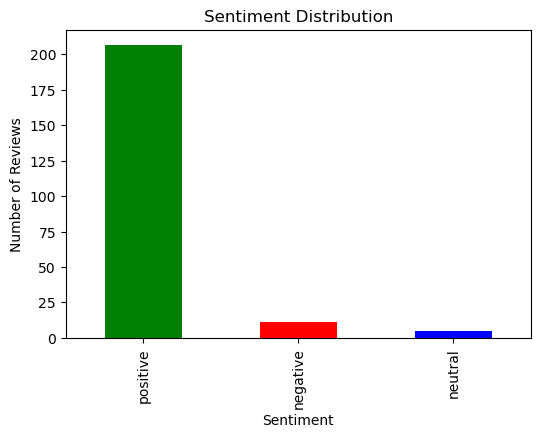

In [33]:
#Sentiment Distribution (Bar Chart)
import matplotlib.pyplot as plt

# Count sentiment labels
sentiment_counts = df['sentiment_label'].value_counts()

# Plot bar chart
plt.figure(figsize=(6,4))
sentiment_counts.plot(kind='bar', color=['green','red','blue'])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [35]:
!pip install wordcloud

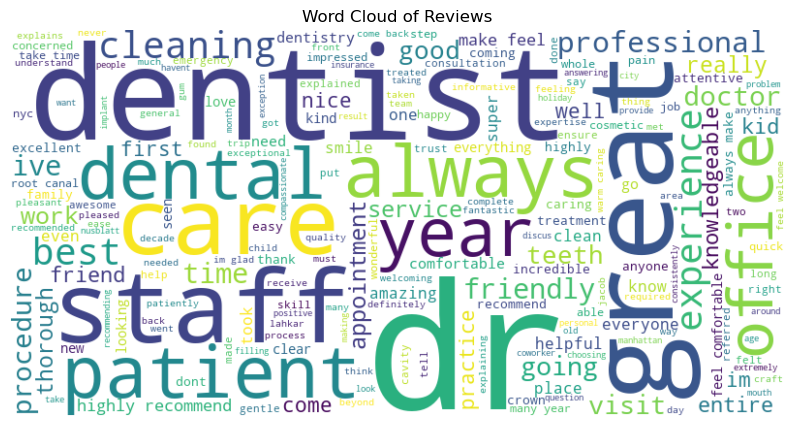

In [36]:
#Word Cloud (Most Frequent Words)
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join all lemmatized tokens into one string
all_words = ' '.join([' '.join(tokens) for tokens in df['lemmatized_tokens']])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

# Display
plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Reviews")
plt.show()

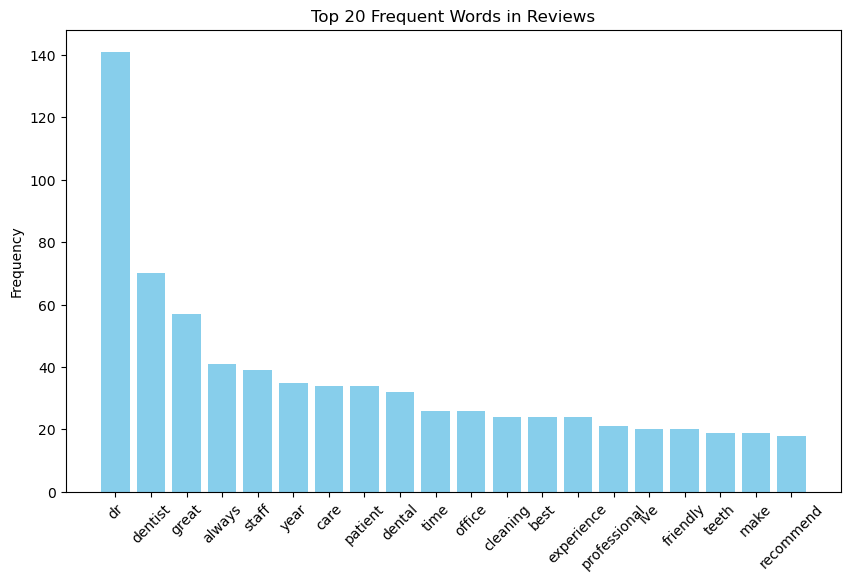

In [37]:
#Theme Frequency (Top 20 Words)
from collections import Counter

# Flatten list of tokens
all_tokens = [word for tokens in df['lemmatized_tokens'] for word in tokens]

# Count word frequencies
word_freq = Counter(all_tokens)

# Get top 20 words
common_words = word_freq.most_common(20)

# Plot
words, counts = zip(*common_words)
plt.figure(figsize=(10,6))
plt.bar(words, counts, color='skyblue')
plt.xticks(rotation=45)
plt.title("Top 20 Frequent Words in Reviews")
plt.ylabel("Frequency")
plt.show()

In [38]:
#sentimental distribution
print(df['sentiment_label'].value_counts())

sentiment_label
positive    207
negative     11
neutral       5
Name: count, dtype: int64


In [39]:
#Dominant Themes in Reviews  
from collections import Counter

all_tokens = [word for tokens in df['lemmatized_tokens'] for word in tokens]
word_freq = Counter(all_tokens)
print(word_freq.most_common(10))

[('dr', 141), ('dentist', 70), ('great', 57), ('always', 41), ('staff', 39), ('year', 35), ('care', 34), ('patient', 34), ('dental', 32), ('time', 26)]


In [40]:
#Model Performance  
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

Logistic Regression Accuracy: 0.9111111111111111
Naive Bayes Accuracy: 0.9111111111111111
SVM Accuracy: 0.9333333333333333


In [41]:
# Save the cleaned dataset to a CSV file
df.to_csv("cleaned_learnData.csv", index=False)

print("Cleaned dataset saved as cleaned_learnData.csv")

Cleaned dataset saved as cleaned_learnData.csv
